### **Package**

In [5]:
import subprocess
import sys
import os

print(sys.version)

for pkg in ["pymoo", "GPy", "autogluon.tabular", "pyro-ppl"]:
    module_name = pkg.split('.')[0]
    try:
        __import__(pkg)
        print(f"{pkg} is already installed.")
    except ImportError:
        print(f"{pkg} is not installed. Installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print(f"{pkg} installed.")


import warnings
warnings.filterwarnings("ignore", message=".*load_learner.*pickle.*")

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pymoo is already installed.
GPy is already installed.
autogluon.tabular is already installed.
pyro-ppl is not installed. Installing...
pyro-ppl installed.


In [6]:
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/PhD 2026 Offline data-driven MOO under uncertainty')

from src.opt_problem import build_problem, Benchmark_Problem, EvaluatePreRealCallback, evaluate_pre_real
from src.survival import Survival_standard, Survival_dual_ranking
from src.data import generate_data
from src.metrics import get_metrics
from src.models import GPR_RBF, gpr_pred_mean_std
from src.uncertainty import coverage, find_alpha
from src.experiment import run_experiment
from src.other_functions import mean_std, print_gpr_params
from src.plotting import plot_z_score, plot_obj_2d

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Main**

###### 1. Initial settings

In [7]:
# Problem: dtlz1-7, omnitest, bnh, truss2d, welded_beam
problem_name = 'dtlz1'
n_var = 10
n_obj = 2
problem = build_problem(
    problem_name = problem_name,
    n_var = n_var,
    n_obj = n_obj)
print(f"Problem name: {problem_name}")
print(f"Cons: {problem.n_constr}")
print(f"Var: {n_var}")
print(f"Obj: {n_obj}")

# EC algorithm: n_gen, pop_size
n_gen = 100
pop_size = 100

# Data: LHS sampling with seed 42
random_seed = 42
sampling = LHS()
sample_size = 11*n_var-1
X_train, y_train, X_val, y_val, X_test, y_test = generate_data(
    problem=problem,
    sample_size=sample_size,
    sampling = sampling,
    train_seed=random_seed,
    val_size=100,
    test_size=100,
    test_seed=1)
y_train_f1 = y_train[:, 0]
y_train_f2 = y_train[:, 1]
print(f"\nSampling X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

# Metrics
hv, igd_plus, obj_min, obj_max, ref_point = get_metrics(
    problem_name = problem_name,
    problem = problem,
    n_var=n_var,
    n_obj=n_obj)
print('\nMin-Max normalization -> Min: ', obj_min)
print('Min-Max normalization -> Max: ', obj_max)
print('HV Reference points: ', ref_point)

np.set_printoptions(precision=4, suppress=True)

Problem name: dtlz1
Cons: 0
Var: 10
Obj: 2

Sampling X_train shape: (109, 10)
y_train shape: (109, 2)
y_val shape: (100, 2)
y_test shape: (100, 2)

Min-Max normalization -> Min:  [0 0]
Min-Max normalization -> Max:  [700 700]
HV Reference points:  [1.1 1.1]


###### 2. Surrogate model training

In [8]:
model_f1 = GPR_RBF()
model_f2 = GPR_RBF()

model_f1.fit(X_train, y_train_f1)
model_f2.fit(X_train, y_train_f2)
print_gpr_params(model_f1, model_f2)

# Predict
pred_mean, pred_std, mean_f1, std_f1, mean_f2, std_f2 = gpr_pred_mean_std(
    model_f1,
    model_f2,
    X_test,
    noiseless=False)
print(f"\nGPR(RBF) MSE: {mean_squared_error(y_test, pred_mean):.2e}\n")

f1 lengthscale: [  1.8323  20.5002 487.9242  33.738   27.1506 770.0908 138.0009 271.7149
 610.1232 530.1334]
f1 kernel variance: [12.811]
f1 noise: [0.1875]
f2 lengthscale: [    1.0359 19125.9641     3.4437 23025.8925 15948.8549 19731.5852
    12.3385 26808.5642 28713.6129    14.8014]
f2 kernel variance: [4.4718]
f2 noise: [0.1124]

GPR(RBF) MSE: 4.67e+03



###### 2.1 CICP & Z score

k=1.645: per_dim=[93. 84.]%, overall=88.5%


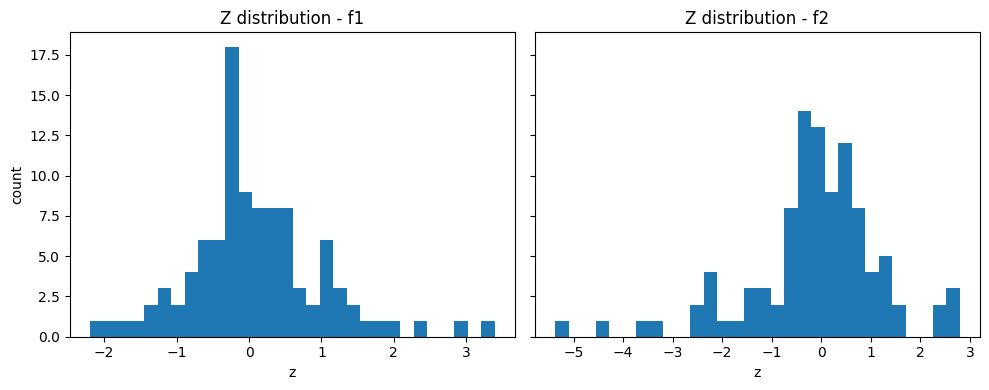

In [9]:
###### CICP
"""
Interval    Coverage
±1.282σ      80.00%
±1.645σ      90.00%
±1.960σ      95.00%
"""

for k in [1.645]:
    per_dim, overall = coverage(y_test, pred_mean, pred_std, k=k)
    print(f"k={k}: per_dim={per_dim*100}%, overall={overall*100:.1f}%")

###### Z score
plot_z_score(y_test, pred_mean, pred_std)

###### 2.2 find_alpha

In [10]:
# ===== target coverage = 0.80 =====
alpha_c80_f1 = find_alpha(
    X_val, y_val[:, 0],
    model_f1,
    target_coverage=0.8)
alpha_c80_f2 = find_alpha(
    X_val, y_val[:, 1],
    model_f2,
    target_coverage=0.8)
print(f"alpha_c80_f1={alpha_c80_f1:.2f}, alpha_c80_f2={alpha_c80_f2:.2f}")

F_upper_c80 = np.stack(
    [mean_f1 + alpha_c80_f1 * std_f1,
     mean_f2 + alpha_c80_f2 * std_f2],
    axis=1)
print('F_upper_c80\n', F_upper_c80[0:5], '\n')

# ===== target coverage = 0.90 =====
alpha_c90_f1 = find_alpha(
    X_val, y_val[:,0],
    model_f1,
    target_coverage=0.9)
alpha_c90_f2 = find_alpha(
    X_val, y_val[:,1],
    model_f2,
    target_coverage=0.9)
print(f"alpha_c90_f1={alpha_c90_f1:.2f}, alpha_c90_f2={alpha_c90_f2:.2f}")

F_upper_c90 = np.stack(
    [mean_f1 + alpha_c90_f1 * std_f1,
     mean_f2 + alpha_c90_f2 * std_f2], axis=1)
print('F_upper_c90\n', F_upper_c90[0:5],'\n')

# ===== target coverage = 0.95 =====
alpha_c95_f1 = find_alpha(
    X_val, y_val[:, 0],
    model_f1,
    target_coverage=0.95)
alpha_c95_f2 = find_alpha(
    X_val, y_val[:, 1],
    model_f2,
    target_coverage=0.95)
print(f"alpha_c95_f1={alpha_c95_f1:.2f}, alpha_c95_f2={alpha_c95_f2:.2f}")

F_upper_c95 = np.stack(
    [mean_f1 + alpha_c95_f1 * std_f1,
     mean_f2 + alpha_c95_f2 * std_f2],
    axis=1)
print('F_upper_c95\n', F_upper_c95[0:5], '\n')

coverage=80.00%
coverage=80.00%
alpha_c80_f1=0.54, alpha_c80_f2=0.63
F_upper_c80
 [[357.5645 190.9548]
 [183.053  376.3563]
 [118.6796 469.2046]
 [ 56.5639 549.2057]
 [138.7516 424.3331]] 

coverage=90.00%
coverage=90.00%
alpha_c90_f1=1.23, alpha_c90_f2=1.05
F_upper_c90
 [[402.8568 213.8905]
 [228.2782 399.2677]
 [164.1419 492.5088]
 [102.6406 572.5722]
 [184.1139 447.1878]] 

coverage=95.00%
coverage=95.00%
alpha_c95_f1=1.75, alpha_c95_f2=1.64
F_upper_c95
 [[436.9901 246.1098]
 [262.3609 431.4528]
 [198.4033 525.2457]
 [137.3651 605.3965]
 [218.2999 479.2931]] 



###### 3. Optimization

In [11]:
runtime_records = []
start_time = time.perf_counter()
results = run_experiment(
    problem=problem,
    problem_name=problem_name,
    n_gen=n_gen,
    pop_size=pop_size,
    model_f1=model_f1,
    model_f2=model_f2,
    obj_min=obj_min,
    obj_max=obj_max,
    hv=hv,
    igd_plus=igd_plus,
    use_surrogate="GPR_uncertainty", ### change
    survival_function=Survival_standard(), ### change
    use_callback=False, ### change
    seeds=range(1, 31)) ### change
seed_runtimes = [run_detail["time"] for run_detail in results["run_details"]]
runtime_mean = float(np.mean(seed_runtimes))
runtime_std = float(np.std(seed_runtimes))
runtime_records.append(runtime_mean)
print(f"Exp1 runtime over {len(seed_runtimes)} seeds: mean={runtime_mean:.2f}s, std={runtime_std:.2f}s")

mse_list = results["mse_list"]
igd_list = results["igd_list"]
hv_surrogate_list = results["hv_surrogate_list"]
hv_real_list = results["hv_real_list"]

obj = results["run_details"][-1]["obj"]
f_real = results["run_details"][-1]["f_real"]
solution = results["run_details"][-1]["solution"]

plot_obj_2d(obj,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))
plot_obj_2d(f_real,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))


Seed 1 | Time: 11.34s | MSE: 7.62e+03 | igd+: 1.37e+02 | Sur HV: 1.03 | Real HV: 1.16 | Max obj: [444.8717 515.8631] | Max f_real: [387.5999 393.4155]
Seed 2 | Time: 8.20s | MSE: 9.90e+03 | igd+: 1.01e+02 | Sur HV: 1.03 | Real HV: 1.17 | Max obj: [444.8962 514.6106] | Max f_real: [374.0489 390.3563]
Seed 3 | Time: 10.47s | MSE: 9.71e+03 | igd+: 1.50e+02 | Sur HV: 1.03 | Real HV: 1.16 | Max obj: [444.9453 451.7741] | Max f_real: [305.8288 382.8822]
Seed 4 | Time: 8.44s | MSE: 1.28e+04 | igd+: 1.11e+02 | Sur HV: 1.03 | Real HV: 1.17 | Max obj: [444.6787 510.0227] | Max f_real: [328.2544 320.8537]
Seed 5 | Time: 10.22s | MSE: 1.06e+04 | igd+: 1.26e+02 | Sur HV: 1.03 | Real HV: 1.17 | Max obj: [445.0187 514.591 ] | Max f_real: [374.0974 358.985 ]
Seed 6 | Time: 7.58s | MSE: 6.00e+03 | igd+: 1.40e+02 | Sur HV: 1.03 | Real HV: 1.16 | Max obj: [445.3708 514.0055] | Max f_real: [389.1716 399.7941]
Seed 7 | Time: 9.78s | MSE: 8.77e+03 | igd+: 8.22e+01 | Sur HV: 1.03 | Real HV: 1.17 | Max obj: [

In [12]:
mean_mse, std_mse = mean_std(mse_list)
mean_igd, std_igd = mean_std(igd_list)
mean_hv_real, std_hv_real = mean_std(hv_real_list)
mean_hv_surrogate, std_hv_surrogate = mean_std(hv_surrogate_list)

print('Problem name: ', problem_name)
print("\n=== GPR ===")

print(f"MSE: Mean = {mean_mse:.3e}, Std = {std_mse:.3e}")
print(f"IGD+: Mean = {mean_igd:.3e}, Std = {std_igd:.3e}")
print(f"Sur HV: Mean = {mean_hv_surrogate:.3f}, Std = {std_hv_surrogate:.3f}")
print(f"Real HV: Mean = {mean_hv_real:.3f}, Std = {std_hv_real:.3f}")

Problem name:  dtlz1

=== GPR ===
MSE: Mean = 1.012e+04, Std = 2.537e+03
IGD+: Mean = 1.083e+02, Std = 2.311e+01
Sur HV: Mean = 1.026, Std = 0.000
Real HV: Mean = 1.170, Std = 0.010


###### 3. Optimization GPR (GBF) + dual-ranking (c=0.90)

In [15]:
start_time = time.perf_counter()
results = run_experiment(
    problem=problem,
    problem_name=problem_name,
    n_gen=n_gen,
    pop_size=pop_size,
    model_f1=model_f1,
    model_f2=model_f2,
    obj_min=obj_min,
    obj_max=obj_max,
    hv=hv,
    igd_plus=igd_plus,
    use_surrogate="GPR_uncertainty", ### change
    survival_function=Survival_dual_ranking(
        alpha_f1=alpha_c90_f1,
        alpha_f2=alpha_c90_f2), ### change
    use_callback=False, ### change
    seeds=range(1, 31)) ### change
seed_runtimes = [run_detail["time"] for run_detail in results["run_details"]]
runtime_mean = float(np.mean(seed_runtimes))
runtime_std = float(np.std(seed_runtimes))
runtime_records.append(runtime_mean)
print(f"Exp2 runtime over {len(seed_runtimes)} seeds: mean={runtime_mean:.2f}s, std={runtime_std:.2f}s")
print(f"Optimization runtime summary (Exp1-Exp{len(runtime_records)} block means): mean={np.mean(runtime_records):.2f}s, std={np.std(runtime_records):.2f}s")

mse_list = results["mse_list"]
igd_list = results["igd_list"]
hv_surrogate_list = results["hv_surrogate_list"]
hv_real_list = results["hv_real_list"]

obj = results["run_details"][-1]["obj"]
f_real = results["run_details"][-1]["f_real"]
solution = results["run_details"][-1]["solution"]

plot_obj_2d(obj,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))
plot_obj_2d(f_real,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))


Seed 1 | Time: 7.90s | MSE: 8.78e+03 | igd+: 1.26e+02 | Sur HV: 1.03 | Real HV: 1.16 | Max obj: [444.77   514.0389] | Max f_real: [386.5693 393.9242]
Seed 2 | Time: 10.26s | MSE: 1.48e+04 | igd+: 9.54e+01 | Sur HV: 1.03 | Real HV: 1.19 | Max obj: [444.6461 515.3285] | Max f_real: [410.5927 312.7015]
Seed 3 | Time: 14.71s | MSE: 1.38e+04 | igd+: 8.92e+01 | Sur HV: 1.03 | Real HV: 1.18 | Max obj: [444.4838 511.0146] | Max f_real: [343.6854 301.072 ]
Seed 4 | Time: 7.73s | MSE: 1.36e+04 | igd+: 1.03e+02 | Sur HV: 1.03 | Real HV: 1.18 | Max obj: [444.9066 515.2983] | Max f_real: [321.9566 355.9981]
Seed 5 | Time: 9.05s | MSE: 7.42e+03 | igd+: 1.22e+02 | Sur HV: 1.03 | Real HV: 1.16 | Max obj: [445.2901 509.2465] | Max f_real: [384.8263 550.092 ]
Seed 6 | Time: 8.61s | MSE: 1.33e+04 | igd+: 9.66e+01 | Sur HV: 1.03 | Real HV: 1.18 | Max obj: [444.5837 513.505 ] | Max f_real: [342.1978 340.0676]
Seed 7 | Time: 8.23s | MSE: 7.91e+03 | igd+: 1.35e+02 | Sur HV: 1.03 | Real HV: 1.16 | Max obj: [4

In [16]:
mean_mse, std_mse = mean_std(mse_list)
mean_igd, std_igd = mean_std(igd_list)
mean_hv_real, std_hv_real = mean_std(hv_real_list)
mean_hv_surrogate, std_hv_surrogate = mean_std(hv_surrogate_list)

print('Problem name: ', problem_name)
print("\n=== GPR + dual-ranking (alpha_c90) ===")

print(f"MSE: Mean = {mean_mse:.3e}, Std = {std_mse:.3e}")
print(f"IGD+: Mean = {mean_igd:.3e}, Std = {std_igd:.3e}")
print(f"Sur HV: Mean = {mean_hv_surrogate:.3f}, Std = {std_hv_surrogate:.3f}")
print(f"Real HV: Mean = {mean_hv_real:.3f}, Std = {std_hv_real:.3f}")

Problem name:  dtlz1

=== GPR + dual-ranking (alpha_c90) ===
MSE: Mean = 9.426e+03, Std = 2.979e+03
IGD+: Mean = 1.155e+02, Std = 2.531e+01
Sur HV: Mean = 1.026, Std = 0.000
Real HV: Mean = 1.166, Std = 0.017
